EMPLOYEE ATTENDANCE DATA CLEANING

In [1]:
import pandas as pd
import numpy as np

LOAD THE DATASET

In [2]:
file_path="/content/Employee_Attendance.csv"
df=pd.read_csv(file_path)
print("Original Shape:",df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
print(df.head())

Original Shape: (1530, 15)

Column Names:
['Employee_ID', 'Employee_Name', 'Department', 'Designation', 'Location', 'Employment_Type', 'Joining_Date', 'Attendance_Date', 'Attendance_Status', 'Late_Minutes', 'Overtime_Hours', 'Basic_Salary', 'Allowance', 'Work_Email', 'Employee_Status']

First 5 Rows:
  Employee_ID     Employee_Name  Department           Designation    Location  \
0     EMP2001       Sneha Patel          IT      Python Developer  Trivandrum   
1     EMP2002        Neha Patel          HR            HR Manager   Bengaluru   
2     EMP2003        Vishnu Das  Operations  Operations Executive       Kochi   
3     EMP2004    Nikhil Sharma      Finance       Finance Analyst  Trivandrum   
4     EMP2005        Meera Iyer          IT     Software Engineer   Bengaluru   

  Employment_Type         Joining_Date      Attendance_Date Attendance_Status  \
0       Full Time  2022-12-12 00:00:00  2025-03-27 00:00:00           Present   
1       Full Time  2025-02-26 00:00:00  2025-01-0

CHECK MISSING VALUES

In [3]:
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())


Missing Values Before Cleaning:
Employee_ID          13
Employee_Name         0
Department           17
Designation          17
Location             13
Employment_Type       0
Joining_Date         18
Attendance_Date      11
Attendance_Status     0
Late_Minutes         30
Overtime_Hours        7
Basic_Salary         23
Allowance             3
Work_Email           22
Employee_Status       5
dtype: int64


REMOVE EXACT DUPLICATE RECORDS

In [4]:
duplicate_count=df.duplicated().sum()
print("\nDuplicate Rows:",duplicate_count)
df=df.drop_duplicates()
print("Shape After Removing Duplicates:",df.shape)



Duplicate Rows: 30
Shape After Removing Duplicates: (1500, 15)


REMOVE LEADING/TRAILING SPACES

In [5]:
df.columns=df.columns.str.strip()
text_columns=df.select_dtypes(include="object").columns
for col in text_columns:
  df[col]=df[col].astype(str).str.strip()

CONVERT DATE COLUMNS

In [6]:
if "Joining_Date" in df.columns:
  df["Joining_Date"]=pd.to_datetime(

  df["Joining_Date"],
  errors="coerce"
  )
if "Attendance_Date" in df.columns:
  df["Attendance_Date"]=pd.to_datetime(
      df["Attendance_Date"],
      errors="coerce"
  )

CONVERT NUMERIC COLUMNS

In [7]:
numeric_columns=[
    "Age",
    "Late_Minutes",
    "Overtime_Hours",
    "Basic_Salary",
    "Allowance"
]
for col in numeric_columns:
  if col in df.columns:
    df[col]=pd.to_numeric(
        df[col],
        errors="coerce"
    )

HANDLE MISSING NUMERIC VALUES (Using median to reduce outlier influence)

In [8]:
for col in numeric_columns:
  if col in df.columns:
    median_value=df[col].median()
    df[col]=df[col].fillna(median_value)

STANDARDIZE DEPARTMENT NAMES

In [9]:
if "Department" in df.columns:
  df["Department"]=(
      df["Department"]
      .str.strip()
      .str.title()
  )
  department_mapping={
      "Hr":"HR",
      "Human Resources":"HR",
      "iT":"it",
      "Information Technology":"IT",
      "Finance":"Finance",
  }
  df["Department"]=df["Department"].replace(
      department_mapping
  )

STANDARDIZE LOCATION NAMES

In [10]:
if "Location" in df.columns:
  df["Location"]=(
      df["Location"]
      .str.strip()
      .str.title()
  )
  location_mapping={
      "Bangalore":"Bengaluru",
      "Banglore":"Bengaluru",
      "Bengaluru":"Bengaluru",
      "Trivandrum":"Trivandrum",
      "Cochin":"Kochi"
  }
  df["Location"]=df["Location"].replace(
      location_mapping

  )

STANDARDIZE EMPLOYMENT TYPE

In [11]:
if "Employment_Type" in df.columns:
  df["Employment_Type"]=(
      df["Employment_Type"]
      .str.strip()
      .str.title()
  )
  employment_mapping={
      "Full-Time":"Full Time",
      "Fulltime":"Fukk Time",
      "Part-Time":"Part Time",
      "Parttime":"Contract",
      "Contractual":"Contract",
      "Internship":"Intern"

  }
  df["Employment_Type"]=df[
      "Employment_Type"

  ].replace(employment_mapping)

STANDARDIZE ATTENDANCE STATUS

In [12]:
if "Attendance_Status" in df.columns:
  df["Attendance_Status"]=(
      df["Attendance_Status"]
      .str.strip()
      .str.title()
  )
  attendance_mapping={
      "Present":"Present",
      "P":"Present",
      "Absent":"Absent",
      "A":"Absent",
      "Work From Home":"WFH",
      "Work From Home":"WFH",
      "Half-Day":"Half Day",
      "Halfday":"Half Day"
  }

  df["Attendance_Status"]=df[
      "Attendance_Status"
  ].replace(attendance_mapping)



REMOVE ATTENDANCE RECORDS BEFORE JOINING

In [13]:
if "Joining_Date" in df.columns and "Attendance_Date" in df.columns:
  invalid_date=(
      df["Attendance_Date"]<df["Joining_Date"]
  )
  print(
      "\nAttendance records before joining date:",
      invalid_date.sum()
  )
  df=df[~invalid_date]
  print("Shape After Removing Invalid Records:",df.shape)


Attendance records before joining date: 137
Shape After Removing Invalid Records: (1363, 15)


CREATE TOTAL COMPENSATION

In [14]:
if "Basic_Salary" in df.columns and "Allowance" in df.columns:
    df = df.copy()
    df.loc[:, "Total_Compensation"] = (
        df["Basic_Salary"] + df["Allowance"]
    )

CREATE LATE FLAG

In [15]:
# Create Late Flag
if "Late_Minutes" in df.columns:
    df = df.copy()
    df.loc[:, "Late_Flag"] = df["Late_Minutes"] > 0

CREATE OVERTIME FLAG

In [16]:
# Create Overtime Flag
if "Overtime_Hours" in df.columns:
    df = df.copy()
    df.loc[:, "Overtime_Flag"] = df["Overtime_Hours"] > 0

OUTLIER DETECTION USING IQR

In [17]:
def detect_outilers_iqr(data,column):
  Q1=data[column].quantile(0.25)
  Q3=data[column].quantile(0.75)
  IQR=Q3-Q1
  lower_limit=Q1-1.5 * IQR
  upper_limit=Q3 +1.5 * IQR
  return (
      (data[column]< lower_limit) |
      (data[column]>upper_limit)

  )
  outlier_columns=[
      "Age",
      "Late_Minutes",
      "Overtime_Hours",
      "Basic_Salary",
      "Allowance"
  ]

  for col in outlier_columns:
    if col in df.columns:
      df[col + "_Outlier"]=detect_outlier_iqr(
          df,
          col
      )

EMAIL VALIDATION

In [18]:
if "Email" in df.columns:

    email_pattern = (
        r"^[A-Za-z0-9._%+-]+@"
        r"[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"
    )

    df["Email_Valid"] = df["Email"].str.match(
        email_pattern,
        na=False
    )


    df.loc[
        ~df["Email_Valid"],
        "Email"
    ] = np.nan

CREATE YEAR AND MONTH FIELDS

In [19]:
# Create a proper independent copy
df = df.copy()

# Convert Attendance_Date to datetime
df["Attendance_Date"] = pd.to_datetime(
    df["Attendance_Date"],
    errors="coerce"
)

# Create Year, Month and Month Name
df.loc[:, "Attendance_Year"] = df["Attendance_Date"].dt.year

df.loc[:, "Attendance_Month"] = df["Attendance_Date"].dt.month

df.loc[:, "Attendance_Month_Name"] = (
    df["Attendance_Date"].dt.strftime("%B")
)

print(df[[
    "Attendance_Date",
    "Attendance_Year",
    "Attendance_Month",
    "Attendance_Month_Name"
]].head())

  Attendance_Date  Attendance_Year  Attendance_Month Attendance_Month_Name
0      2025-03-27           2025.0               3.0                 March
2      2025-09-15           2025.0               9.0             September
3      2025-09-10           2025.0               9.0             September
5      2025-05-07           2025.0               5.0                   May
6      2025-04-02           2025.0               4.0                 April


CHECK FINAL MISSING VALUES

In [20]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
Employee_ID               0
Employee_Name             0
Department                0
Designation               0
Location                  0
Employment_Type           0
Joining_Date             20
Attendance_Date          15
Attendance_Status         0
Late_Minutes              0
Overtime_Hours            0
Basic_Salary              0
Allowance                 0
Work_Email                0
Employee_Status           0
Total_Compensation        0
Late_Flag                 0
Overtime_Flag             0
Attendance_Year          15
Attendance_Month         15
Attendance_Month_Name    15
dtype: int64


CHECK FINAL DUPLICATES

In [21]:
print(
    "\nDuplicates After Cleaning:",
    df.duplicated().sum()
)


Duplicates After Cleaning: 0


FINAL DATASET INFORMATION

In [22]:
print("\nFinal Dataset Shape:")
print(df.shape)
print("\nFinal Dataset Info:")
print(df.info())
print("\nFinal 5 Rows:")
print(df.tail())


Final Dataset Shape:
(1363, 21)

Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1363 entries, 0 to 1498
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Employee_ID            1363 non-null   object        
 1   Employee_Name          1363 non-null   object        
 2   Department             1363 non-null   object        
 3   Designation            1363 non-null   object        
 4   Location               1363 non-null   object        
 5   Employment_Type        1363 non-null   object        
 6   Joining_Date           1343 non-null   datetime64[ns]
 7   Attendance_Date        1348 non-null   datetime64[ns]
 8   Attendance_Status      1363 non-null   object        
 9   Late_Minutes           1363 non-null   float64       
 10  Overtime_Hours         1363 non-null   float64       
 11  Basic_Salary           1363 non-null   float64       
 12  Allowance    

SAVE CLEANED DATASET

In [23]:
output_file="Employee_Attendance_Cleaned.csv"
df.to_csv(
    output_file,
    index=False
)
print(
    f"\nCleaned dataset saved as: {output_file}"
)


Cleaned dataset saved as: Employee_Attendance_Cleaned.csv


EMPLOYEE ATTENDANCE - PYTHON ANALYSIS & EDA

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IMPORT CLEANED DATASET

In [25]:
df=pd.read_csv("/content/Employee_Attendance_Cleaned.csv")
print("Dataset Shape:",df.shape)
print("\ncolumns:")
print(df.columns.tolist())

Dataset Shape: (1363, 21)

columns:
['Employee_ID', 'Employee_Name', 'Department', 'Designation', 'Location', 'Employment_Type', 'Joining_Date', 'Attendance_Date', 'Attendance_Status', 'Late_Minutes', 'Overtime_Hours', 'Basic_Salary', 'Allowance', 'Work_Email', 'Employee_Status', 'Total_Compensation', 'Late_Flag', 'Overtime_Flag', 'Attendance_Year', 'Attendance_Month', 'Attendance_Month_Name']


BASIC DATASET CHECK

In [26]:
print("\n---DATA TYPES---")
print(df.dtypes)
print("\n---DUPLICATES---")
print("Duplicates rows:", df.duplicated().sum())
print("\n---MISSING VALUES---")
print(df.isnull().sum())


---DATA TYPES---
Employee_ID               object
Employee_Name             object
Department                object
Designation               object
Location                  object
Employment_Type           object
Joining_Date              object
Attendance_Date           object
Attendance_Status         object
Late_Minutes             float64
Overtime_Hours           float64
Basic_Salary             float64
Allowance                float64
Work_Email                object
Employee_Status           object
Total_Compensation       float64
Late_Flag                   bool
Overtime_Flag               bool
Attendance_Year          float64
Attendance_Month         float64
Attendance_Month_Name     object
dtype: object

---DUPLICATES---
Duplicates rows: 0

---MISSING VALUES---
Employee_ID               9
Employee_Name             0
Department                0
Designation              16
Location                  0
Employment_Type           0
Joining_Date             20
Attendance_Date     

CONVERT DATA TYPES

In [27]:
df["Joining_Date"]=pd.to_datetime(
    df["Joining_Date"],errors="coerce"
)
df["Attendance_Date"]=pd.to_datetime(
    df["Attendance_Date"],errors="coerce"
)
numeric_columns=[
    "Late_Minutes",
    "Overtime_Hours",
    "Basic_Salary",
    "Allowance",
    "Total_Compensation"
]
for col in numeric_columns:
  df[col]=pd.to_numeric(df[col],errors="coerce")

DESCRIPTIVE STATISTICS

In [28]:
print("\n---DESCRIPTIVE STATISTICS---")
print(df.describe(include="all"))


---DESCRIPTIVE STATISTICS---
       Employee_ID Employee_Name Department           Designation    Location  \
count         1354          1363       1363                  1347        1363   
unique        1354           154         12                    32           8   
top        EMP3499    Rohan Nair      Sales  Operations Executive  Trivandrum   
freq             1            22        188                    71         247   
mean           NaN           NaN        NaN                   NaN         NaN   
min            NaN           NaN        NaN                   NaN         NaN   
25%            NaN           NaN        NaN                   NaN         NaN   
50%            NaN           NaN        NaN                   NaN         NaN   
75%            NaN           NaN        NaN                   NaN         NaN   
max            NaN           NaN        NaN                   NaN         NaN   
std            NaN           NaN        NaN                   NaN         NaN  

WORKFORCE OVERVIEW

In [29]:
print("\n---WORKFORCE OVERVIEW---")
print("Total Employees:",
      df["Employee_ID"].nunique())
print("\nDepartment Distribution:")
print(df["Department"].value_counts())
print("\nEmployment Type Distribution:")
print(df["Employment_Type"].value_counts())
print("\nLocation Distribution:")
print(df["Location"].value_counts())
print("\nEmployee Status:")
print(df["Employee_Status"].value_counts())


---WORKFORCE OVERVIEW---
Total Employees: 1354

Department Distribution:
Department
Sales               188
It                  178
Operations          172
HR                  171
Logistics           170
Marketing           160
Customer Support    157
Finance             141
Nan                  14
I.T.                  7
-                     4
Finanace              1
Name: count, dtype: int64

Employment Type Distribution:
Employment_Type
Contract      359
Intern        346
Full Time     333
Part Time     322
Contractor      3
Name: count, dtype: int64

Location Distribution:
Location
Trivandrum    247
Kochi         233
Hyderabad     227
Bengaluru     223
Calicut       214
Chennai       206
Nan            11
-               2
Name: count, dtype: int64

Employee Status:
Employee_Status
Active       886
Inactive     456
IN-ACTIVE      6
active         5
inactive       4
ACTIVE         2
Name: count, dtype: int64


ATTENDANCE STATUS ANALYSIS

In [30]:
attendance_counts=df["Attendance_Status"].value_counts()
attendance_percentage=(
    df["Attendance_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)

)
print("\n---ATTENDANCE STATUS ---")
print(attendance_counts)
print("\nAttendance Percentage:")
print(attendance_percentage)
present_days=(
    df["Attendance_Status"]=="Present"

).sum()
total_records=len(df)
attendance_rate=(
    present_days/total_records
)*100
print("\nOverall Attendance Rate:",
      round(attendance_rate,2),"%")


---ATTENDANCE STATUS ---
Attendance_Status
Present     560
Absent      221
Wfh         203
Leave       185
Half Day    183
WFH           6
On Leave      5
Name: count, dtype: int64

Attendance Percentage:
Attendance_Status
Present     41.09
Absent      16.21
Wfh         14.89
Leave       13.57
Half Day    13.43
WFH          0.44
On Leave     0.37
Name: proportion, dtype: float64

Overall Attendance Rate: 41.09 %


DEPARTMENT ANALYSIS

In [31]:
department_analysis=df.groupby("Department").agg(
    Records=("Employee_ID","count"),
    Present=("Attendance_Status",
             lambda x: (x=="Present").sum()),
    Absent=("Attendance_Status",
            lambda x: (x=="Absent").sum()),
    Average_Lateness=("Late_Minutes","mean"),
    Total_Overtime=("Overtime_Hours","sum"),
    Average_Overtime=("Overtime_Hours","mean"),
    Average_Salary=("Basic_Salary","mean")
)

department_analysis["Attendance_Rate_%"]=(
    department_analysis["Present"] /
    department_analysis["Records"]*100
)
department_analysis["Absenteeism_Rate_%"]=(
    department_analysis["Absent"] /
    department_analysis["Records"] * 100
)

department_analysis=department_analysis.round(2)
print("\n---DEPARTMENT ANALYSIS---")
print(department_analysis)


---DEPARTMENT ANALYSIS---
                  Records  Present  Absent  Average_Lateness  Total_Overtime  \
Department                                                                     
-                       4        1       0              8.00            14.0   
Customer Support      155       73      21              6.38           607.0   
Finanace                1        0       1              9.00            10.0   
Finance               140       52      21              6.56           530.0   
HR                    169       78      27              6.75           760.0   
I.T.                    7        2       4              7.29            46.0   
It                    177       79      24              6.75           725.0   
Logistics             170       78      23              5.88           613.0   
Marketing             159       68      26              6.78           596.0   
Nan                    14        4       4              5.71            54.0   
Operations   

LOCATION ANALYSIS

In [32]:
location_analysis=df.groupby("Location").agg(
    Records=("Employee_ID","count"),
    Present=("Attendance_Status",
             lambda x:(x=="Present").sum()),
    Absent=("Attendance_Status",
             lambda x:(x=="Absent").sum()),
    Average_Lateness=("Late_Minutes","mean"),
    Total_Overtime=("Overtime_Hours","sum"),
    Average_Overtime=("Overtime_Hours","mean"),
    Average_Salary=("Basic_Salary","mean")
)
location_analysis["Attendance_Rate_%"]=(
    location_analysis["Present"] /
    location_analysis["Records"] * 100
)
location_analysis["Absenteeism_Rate_%"]=(
    location_analysis["Absent"] /
    location_analysis["Records"] * 100
)
location_analysis=location_analysis.round(2)
print("\n---LOCATION ANALYSIS---")
print(location_analysis)


---LOCATION ANALYSIS---
            Records  Present  Absent  Average_Lateness  Total_Overtime  \
Location                                                                 
-                 2        1       0              7.50             0.0   
Bengaluru       222       92      37              6.22           769.0   
Calicut         212       88      37              7.52           912.0   
Chennai         206       93      37              6.28           768.0   
Hyderabad       227       93      39              6.70           975.0   
Kochi           232       94      33              6.14           930.0   
Nan              11        6       4              5.64            42.0   
Trivandrum      242       93      34              6.94          1003.0   

            Average_Overtime  Average_Salary  Attendance_Rate_%  \
Location                                                          
-                       0.00        54856.50              50.00   
Bengaluru               3.45     

MONTHLY ATTENDANCE ANALYSIS

In [33]:
df["Attendance_Month"]=(
    df["Attendance_Date"]
    .dt.to_period("M")
    .astype(str)
)
monthly_analysis=df.groupby("Attendance_Month").agg(
    Records=("Employee_ID","count"),
    Present=("Attendance_Status",
             lambda x:(x=="Present").sum()),
    Absent=("Attendance_Status",
            lambda x:(x=="Absent").sum()),
    Average_Lateness=("Late_Minutes","mean"),
    Total_Overtime=("Overtime_Hours","sum"),

)
monthly_analysis["Attendance_Rate_&"]=(
    monthly_analysis["Present"] /
    monthly_analysis["Records"] * 100
)
monthly_analysis["Absenteeism_Rate_%"]=(
    monthly_analysis["Absent"] /
    monthly_analysis["Records"] * 100
)
monthly_analysis=monthly_analysis.round(2)
print("\n---MONTHLY ANALYSIS---")
print(monthly_analysis)


---MONTHLY ANALYSIS---
                  Records  Present  Absent  Average_Lateness  Total_Overtime  \
Attendance_Month                                                               
2025-01               110       52      10              5.56           428.0   
2025-02                79       37       9              6.84           338.0   
2025-03               112       43      21              7.38           482.0   
2025-04               101       38      21              7.08           469.0   
2025-05               109       48      18              6.75           479.0   
2025-06               102       46      19              6.20           374.0   
2025-07               114       50      15              7.16           442.0   
2025-08               125       52      21              6.04           486.0   
2025-09               111       47      18              6.39           398.0   
2025-10               114       46      19              6.12           446.0   
2025-11         

LATENESS ANALYSIS

In [34]:
print("\n---LATENESS ANALYSIS---")
print("Average Late Minutes:",
      round(df["Late_Minutes"].mean(),2))
print("Maximum Late Minutes:",
      df["Late_Minutes"].max())
late_records=(
    df["Late_Minutes"]>0
).sum()
print("Records with lateness:",
      late_records)
print("\nAverage Lateness by Department:")
print(
    df.groupby("Department")["Late_Minutes"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
print("\nAverage Lateness by Location:")
print(
    df.groupby("Location")["Late_Minutes"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)


---LATENESS ANALYSIS---
Average Late Minutes: 6.63
Maximum Late Minutes: 60.0
Records with lateness: 1271

Average Lateness by Department:
Department
Finanace            9.00
-                   8.00
I.T.                7.29
Sales               7.03
Operations          6.83
Marketing           6.78
HR                  6.75
It                  6.75
Finance             6.56
Customer Support    6.38
Logistics           5.88
Nan                 5.71
Name: Late_Minutes, dtype: float64

Average Lateness by Location:
Location
Calicut       7.52
-             7.50
Trivandrum    6.94
Hyderabad     6.70
Chennai       6.28
Bengaluru     6.22
Kochi         6.14
Nan           5.64
Name: Late_Minutes, dtype: float64


OVERTIME ANALYSIS

In [35]:
print("\n---OVERTIME ANALYSIS---")
print("Total Overtime_Hours:",
      round(df["Overtime_Hours"].sum(),2))
print("Average Overtime_Hours:",
      round(df["Overtime_Hours"].mean(),2))
print("\nOvertime by Department:")
print(
    df.groupby("Department")["Overtime_Hours"]
    .sum()
    .sort_values(ascending=False)
    .round(2)
)
print("\nOvertimr by Location:")
print(
    df.groupby("Location")["Overtime_Hours"]
    .sum()
    .sort_values(ascending=False)
    .round(2)
)



---OVERTIME ANALYSIS---
Total Overtime_Hours: 5399.0
Average Overtime_Hours: 3.96

Overtime by Department:
Department
HR                  760.0
Sales               738.0
It                  725.0
Operations          706.0
Logistics           613.0
Customer Support    607.0
Marketing           596.0
Finance             530.0
Nan                  54.0
I.T.                 46.0
-                    14.0
Finanace             10.0
Name: Overtime_Hours, dtype: float64

Overtimr by Location:
Location
Trivandrum    1003.0
Hyderabad      975.0
Kochi          930.0
Calicut        912.0
Bengaluru      769.0
Chennai        768.0
Nan             42.0
-                0.0
Name: Overtime_Hours, dtype: float64


SALARY ANALYSIS

In [36]:
print("\n---SALARY ANALYSIS---")
print("Average Basic Salary:",
      round(df["Basic_Salary"].mean(),2))
print("Minimum Basic Salary:",
      df["Basic_Salary"].min())
print("Maximum Basic Salary:",
      df["Basic_Salary"].max())
print("\nAverage Salary by Department:")
print(
    df.groupby("Department")["Basic_Salary"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
print("\nAverage Salary by Designation:")
print(
    df.groupby("Designation")["Basic_Salary"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)



---SALARY ANALYSIS---
Average Basic Salary: 56727.29
Minimum Basic Salary: 18078.0
Maximum Basic Salary: 94918.0

Average Salary by Department:
Department
Nan                 62438.82
-                   61351.75
I.T.                60050.57
Finance             58713.72
Marketing           57806.17
Customer Support    57682.53
HR                  57298.67
Logistics           56769.09
Sales               56335.35
Operations          55839.14
It                  53550.53
Finanace            19417.00
Name: Basic_Salary, dtype: float64

Average Salary by Designation:
Designation
Data analyst                      78532.00
Sales executive                   73862.33
Finance Analyst                   62053.17
Accountant                        61373.10
Supply Chain Analyst              60248.20
Marketing Executive               60076.71
Software Engg                     59371.20
Support Executive                 59262.71
HR Executive                      58565.17
Sales Executive               

OUTLIER DETECTION USING IQR

In [37]:
def detect_outlier(data,column):
  Q1=data[column].quantile(0.25)
  Q2=data[column].quantile(0.75)
  IQR=Q3-Q1
  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR
  outliers=data[
      (data[column]<lower_limit) |
      (data[column]>upper_limit)
  ]
  print(f"\n{column}")
  print("Lower Limit:",round(lower_limit,2))
  print("Upper Limit:",round(upper_limit,2))
  print("Outliers:",len(outliers))
  return outliers
  for column in [
      "Late_Minutes",
      "Overtime_Hours",
      "Basic_Salary",
      "Allowance"
  ]:
    detect_outliers(df,column)

VISUALIZATION - ATTENDANCE STATUS

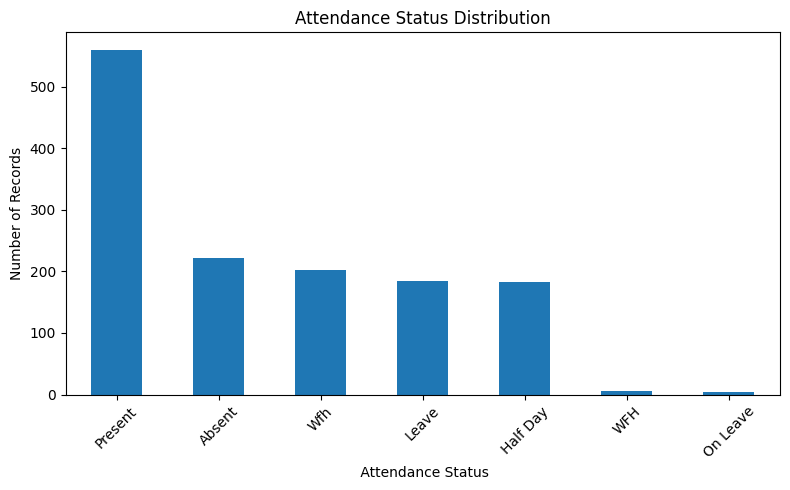

In [38]:
plt.figure(figsize=(8,5))
df["Attendance_Status"].value_counts().plot(
    kind="bar"
)
plt.title("Attendance Status Distribution")
plt.xlabel(" Attendance Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

VISUALIZATION - DEPARTMENT

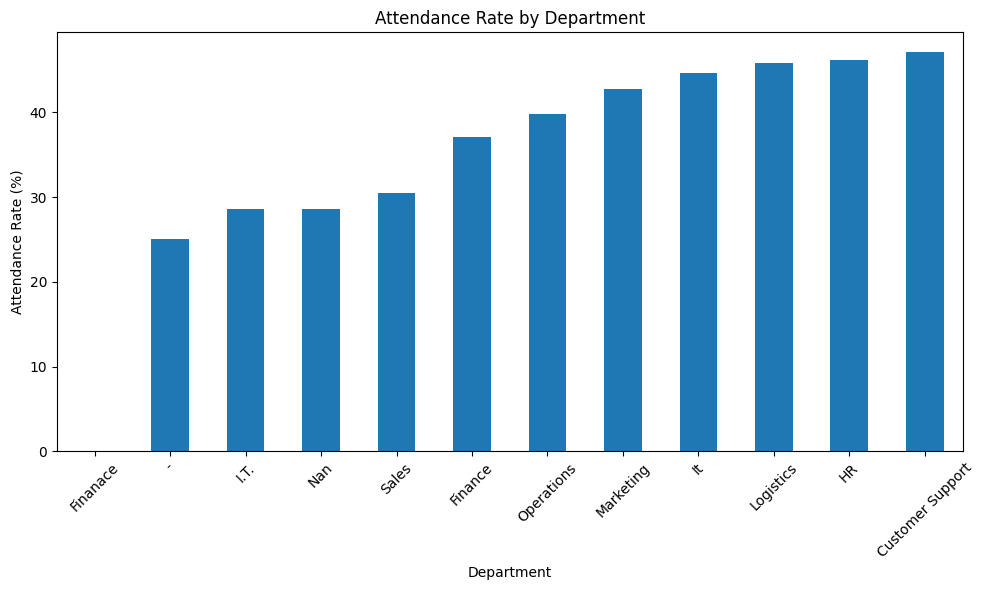

In [39]:
department_analysis[
    "Attendance_Rate_%"
].sort_values().plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Attendance Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attendance Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

VISUALIZATION - LOCATION

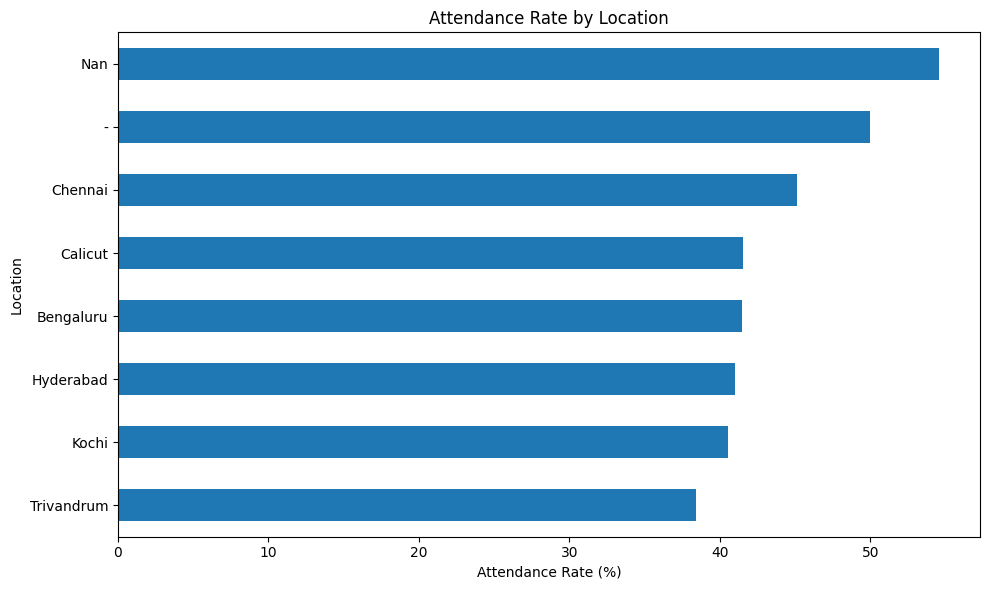

In [40]:
location_analysis[
    "Attendance_Rate_%"
].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)
plt.title("Attendance Rate by Location")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

VISUALIZATION - MONTHLY TREND

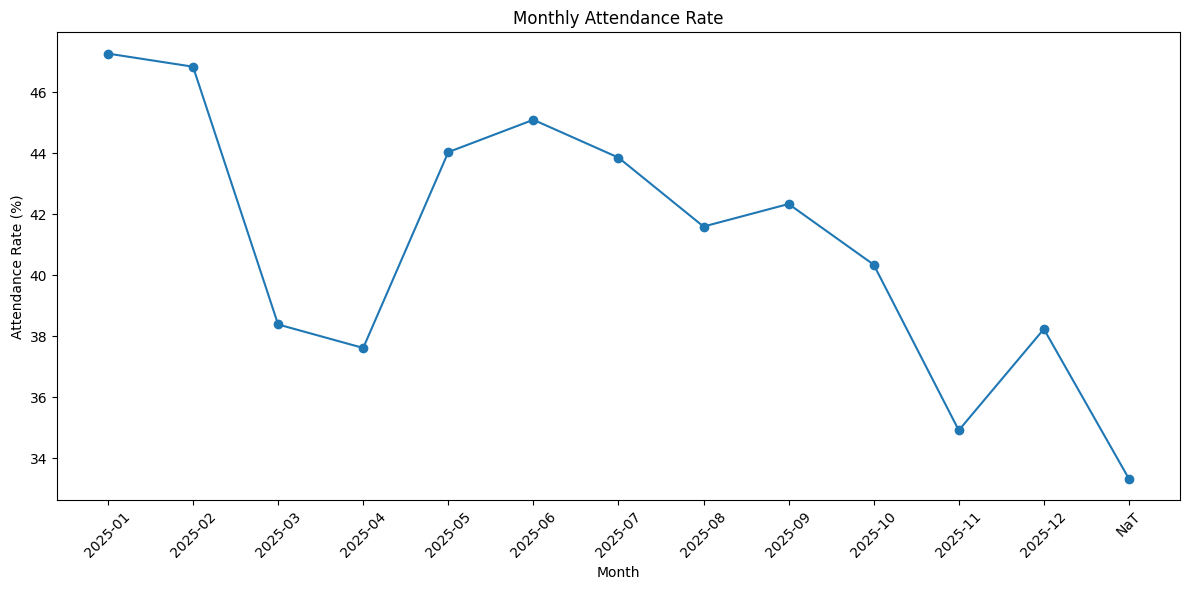

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_analysis.index,
    monthly_analysis["Attendance_Rate_&"],
    marker="o"
)
plt.title("Monthly Attendance Rate")
plt.xlabel("Month")
plt.ylabel("Attendance Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

VISUALIZATION - OVERTIME

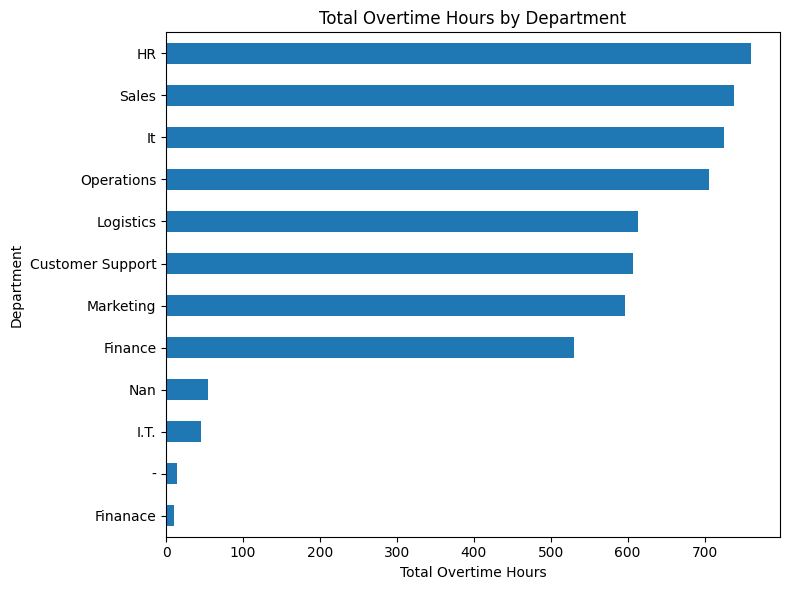

In [47]:
df.groupby("Department")[
    "Overtime_Hours"
].sum().sort_values().plot(
    kind="barh",
    figsize=(8,6)
)
plt.title("Total Overtime Hours by Department")
plt.xlabel("Total Overtime Hours")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

VISUALIZATION - LATENESS

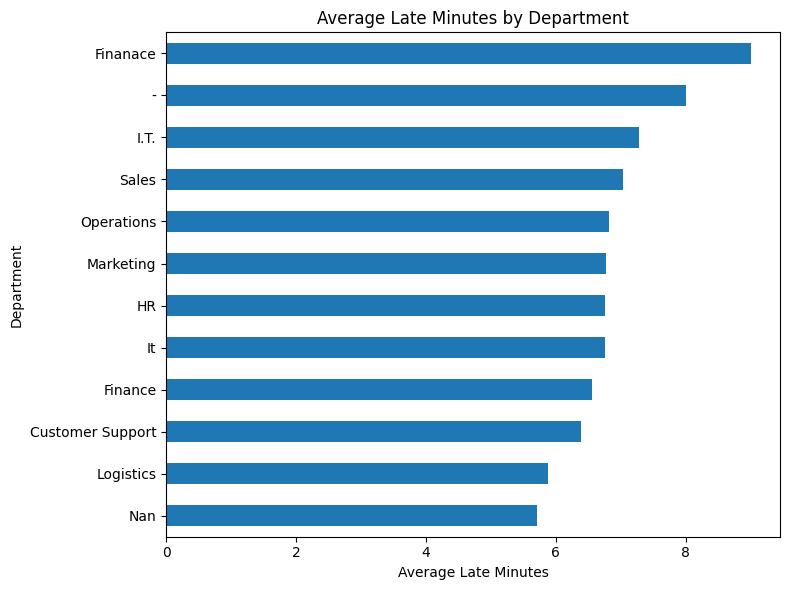

In [48]:
df.groupby("Department")[
    "Late_Minutes"
].mean().sort_values().plot(
    kind="barh",
    figsize=(8,6)
)
plt.title("Average Late Minutes by Department")
plt.xlabel("Average Late Minutes")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


SALARY DISTRIBUTION

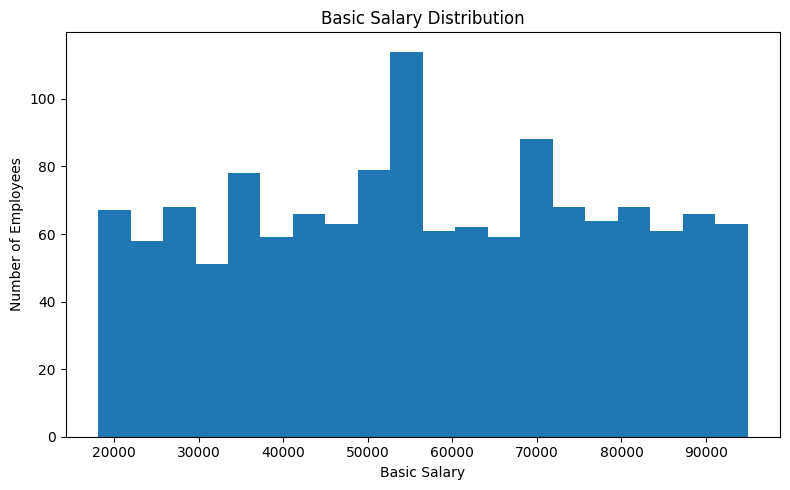

In [49]:
plt.figure(figsize=(8,5))
plt.hist(
    df["Basic_Salary"].dropna(),
    bins=20
)
plt.title("Basic Salary Distribution")
plt.xlabel("Basic Salary")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

FINAL SUMMARY

In [50]:
print("\n====================================")
print("FINAL EDA SUMMARY")
print("====================================")
print("Total Employees:",
      df["Employee_ID"].nunique())
print("Total Attendance Records:",
      len(df))
print("Duplicate Records:",
      df.duplicated().sum())
print("Attenadance Rate:",
      round(attendance_rate,2),"%")
print("Average Late Minutes:",
      round(df["Late_Minutes"].mean(),2))
print("Total Overtime Hours:",
      round(df["Overtime_Hours"].sum(),2))
print("Average Basic Salary:",
      round(df["Basic_Salary"].mean(),2))
print("\nEDA Completed Successfully.")


FINAL EDA SUMMARY
Total Employees: 1354
Total Attendance Records: 1363
Duplicate Records: 0
Attenadance Rate: 41.09 %
Average Late Minutes: 6.63
Total Overtime Hours: 5399.0
Average Basic Salary: 56727.29

EDA Completed Successfully.
